In [74]:
import os
import matplotlib
# matplotlib.use("Agg")  # cluster-safe
import matplotlib.pyplot as plt
import numpy as np

# load x,y,z from figures/model_A0_merit_surface_data.npz
# vanilla_data = np.load("figures/model_vanilla_merit_surface_data.npz")
ws_data = np.load("figures/warmstart_input_merit_surface1.npz")
vanilla_data = np.load("figures/input_merit_surface_dim0_dim121312321.npz")
# ws_data = np.load("figures/model_warmstart_merit_surface_data1.npz")

In [55]:
def plot_merit_contour(
    X, Y, Z,
    *,
    title="Merit landscape",
    levels=30,              # can be int or explicit list/array
    save_path=None,
    dpi=300,
    show=False,
    close=True,
    add_filled=False,       # keep False to match your example
    label_fmt="%.3f",
    label_fontsize=9,
    linewidths=1.6,
):
    plt.figure()

    # Optional: light filled background (keep False to match the example)
    if add_filled:
        plt.contourf(X, Y, Z, levels=levels, alpha=0.25, vmin=-1.6, vmax=13.2)

    # Line contours + labels (this matches your example)
    cs = plt.contour(X, Y, Z, levels=levels, linewidths=linewidths, vmin=-1.6, vmax=13.2)
    plt.clabel(cs, inline=True, fmt=label_fmt, fontsize=label_fontsize)

    plt.xlabel("alpha (x direction)")
    plt.ylabel("beta (y direction)")
    plt.title(title)

    # if save_path is not None:
    #     out_dir = os.path.dirname(save_path)
    #     if out_dir:
    #         os.makedirs(out_dir, exist_ok=True)
    #     plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    #     print(f"Saved plot to: {save_path}", flush=True)

    if show:
        plt.show()
    if close:
        plt.close()


In [56]:
# plot_merit_contour(
#     ws_data["X"], ws_data["Y"], ws_data["Z"],
#     title="model_A0 merit landscape (2 random directions)",
#     save_path="figures/model_A0_merit_surface.png",
#     dpi=300,
#     show=True,
#     levels=10,
# )

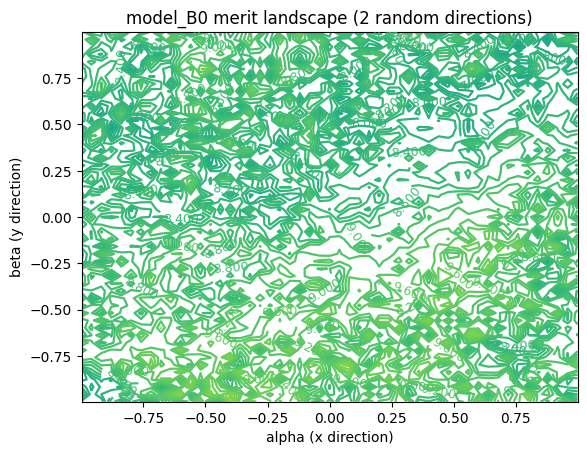

In [75]:
plot_merit_contour(
    vanilla_data["X"], vanilla_data["Y"], vanilla_data["Z"],
    title="model_B0 merit landscape (2 random directions)",
    save_path="figures/model_B0_merit_surface.png",
    dpi=300,
    levels=20,
    show=True,
)

In [58]:
import os
import matplotlib
# matplotlib.use("Agg")  # cluster-safe
import matplotlib.pyplot as plt
import numpy as np

def plot_merit_contour2(
    X, Y, Z,
    *,
    title="Merit landscape",
    levels=30,
    save_path=None,
    dpi=300,
    show=False,
    close=True,
):
    plt.figure()
    cs = plt.contourf(X, Y, Z, levels=levels)
    plt.colorbar(cs)
    plt.xlabel("alpha")
    plt.ylabel("beta")
    plt.title(title)

    # if save_path is not None:
    #     out_dir = os.path.dirname(save_path)
    #     if out_dir:
    #         os.makedirs(out_dir, exist_ok=True)
    #     plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    #     print(f"Saved plot to: {save_path}", flush=True)

    if show:
        plt.show()
    if close:
        plt.close()

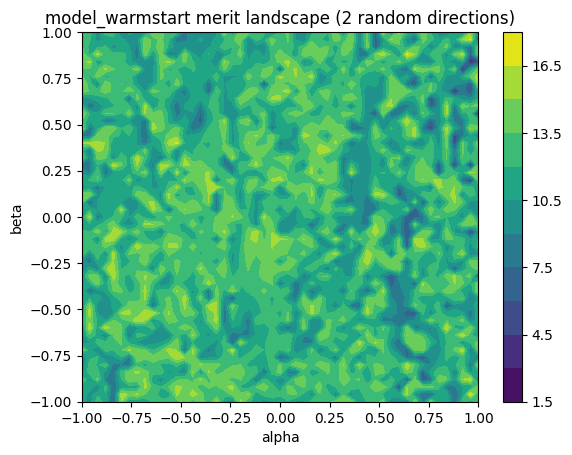

In [59]:
plot_merit_contour2(
    ws_data["X"], ws_data["Y"], ws_data["Z"],
    title="model_warmstart merit landscape (2 random directions)",
    save_path="figures/model_warmstart_merit_surface.png",
    dpi=300,
    show=True,
    levels=10,
)

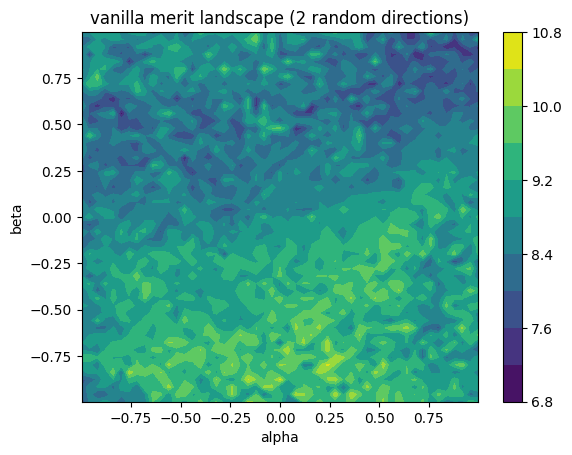

In [60]:
plot_merit_contour2(
    vanilla_data["X"], vanilla_data["Y"], vanilla_data["Z"],
    title="vanilla merit landscape (2 random directions)",
    save_path="figures/model_vanilla_merit_surface.png",
    dpi=300,
    show=True,
    levels=10,
)

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_merit_3d_surface(
    X, Y, Z,
    *,
    title="Merit landscape",
    save_path=None,
    dpi=300,
    show=False,
    close=True,
):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")

    # Surface plot (ghostly smooth surface)
    surf = ax.plot_surface(
        X, Y, Z,
        cmap=cm.GnBu_r,
        alpha=1.0,
        linewidth=0,
        antialiased=True,
        rstride=1,
        cstride=1,
    )

    # Styling (match example)
    ax.set_axis_off()
    ax.set_box_aspect(None, zoom=1.2)
    ax.view_init(elev=50, azim=135)

    if save_path is not None:
        out_dir = os.path.dirname(save_path)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved plot to: {save_path}", flush=True)

    if show:
        plt.show()
    if close:
        plt.close()


Saved plot to: figures/model_B0_merit_surface_3d.png


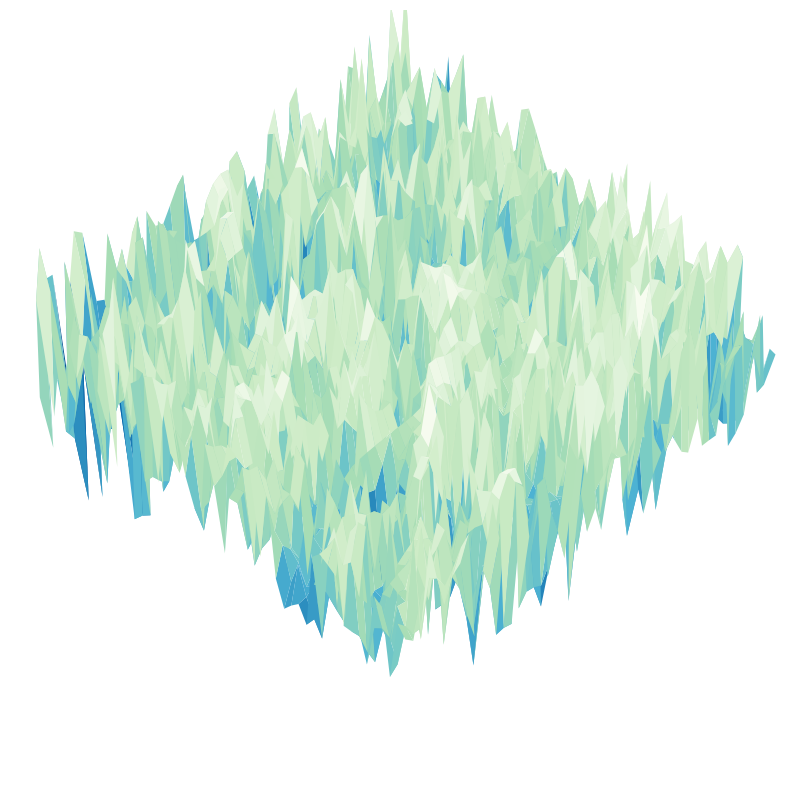

In [62]:
plot_merit_3d_surface(
    ws_data["X"], ws_data["Y"], ws_data["Z"],
    title="model_B0 merit landscape (3D)",
    save_path="figures/model_B0_merit_surface_3d.png",
    dpi=300,
    show=True,
)


Saved plot to: figures/model_B0_merit_surface_3d.png


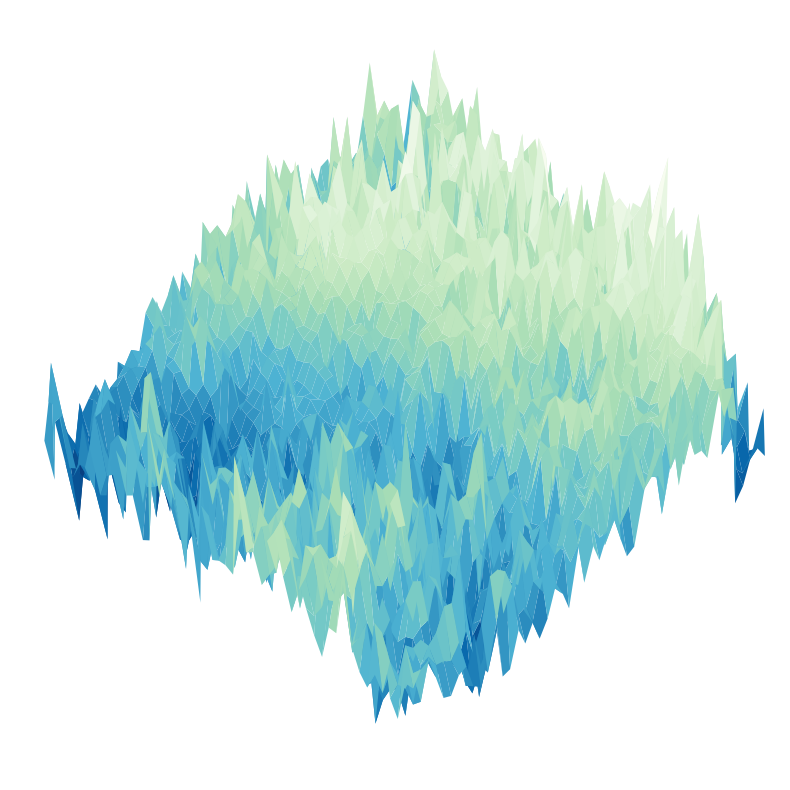

In [76]:
plot_merit_3d_surface(
    vanilla_data["X"], vanilla_data["Y"], vanilla_data["Z"],
    title="model_B0 merit landscape (3D)",
    save_path="figures/model_B0_merit_surface_3d.png",
    dpi=300,
    show=True,
)

In [64]:
def plot_merit_3d_surface_side_by_side(
    X1, Y1, Z1,
    X2, Y2, Z2,
    *,
    title_left="Vanilla",
    title_right="WS",
    save_path=None,
    dpi=300,
    show=False,
    close=True,
):
    fig = plt.figure(figsize=(20, 8))

    # ---------------- Left plot ----------------
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        X1, Y1, Z1,
        cmap=cm.GnBu_r,
        alpha=1.0,
        linewidth=0,
        antialiased=True,
        rstride=2,
        cstride=2,
    )
    ax1.set_axis_off()
    ax1.set_box_aspect(None, zoom=1.2)
    ax1.view_init(elev=50, azim=135)
    ax1.set_title(title_left, pad=20)

    # ---------------- Right plot ----------------
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(
        X2, Y2, Z2,
        cmap=cm.GnBu_r,
        alpha=1.0,
        linewidth=0,
        antialiased=True,
        rstride=2,
        cstride=2,
    )
    ax2.set_axis_off()
    ax2.set_box_aspect(None, zoom=1.2)
    ax2.view_init(elev=50, azim=190)
    ax2.set_title(title_right, pad=20)

    zmin = min(vanilla_data["Z"].min(), ws_data["Z"].min())
    zmax = max(vanilla_data["Z"].max(), ws_data["Z"].max())
    ax1.set_zlim(zmin, zmax)
    ax2.set_zlim(zmin, zmax)

    # if save_path is not None:
    #     out_dir = os.path.dirname(save_path)
    #     if out_dir:
    #         os.makedirs(out_dir, exist_ok=True)
    #     plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    #     print(f"Saved plot to: {save_path}", flush=True)

    if show:
        plt.show()
    if close:
        plt.close()


In [65]:
# plot_merit_3d_surface_side_by_side(
#     vanilla_data["X"], vanilla_data["Y"], vanilla_data["Z"],
#     ws_data["X"], ws_data["Y"], ws_data["Z"],
#     title_left="Vanilla",
#     title_right="WS",
#     save_path="figures/merit_surface_comparison.png",
#     dpi=300,
#     show=True,
# )

In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_merit_3d_surface_side_by_side_fair(
    X1, Y1, Z1,
    X2, Y2, Z2,
    *,
    title_left="Vanilla",
    title_right="WS",
    save_path=None,
    dpi=300,
    show=False,
    close=True,
):
    # Shared height range (CRITICAL for fairness)
    zmin = min(Z1.min(), Z2.min())
    zmax = max(Z1.max(), Z2.max())

    fig = plt.figure(figsize=(20, 8))

    # ---------- Left ----------
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        X1, Y1, Z1,
        cmap=cm.GnBu_r,
        vmin=zmin,
        vmax=zmax,
        shade=False,        # IMPORTANT: no lighting bias
        linewidth=0,
        antialiased=True,
    )
    ax1.set_title(title_left, pad=20)
    ax1.set_axis_off()
    ax1.set_box_aspect(None, zoom=1.2)
    ax1.view_init(elev=50, azim=135)
    ax1.set_zlim(zmin, zmax)

    # ---------- Right ----------
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(
        X2, Y2, Z2,
        cmap=cm.GnBu_r,
        vmin=zmin,
        vmax=zmax,
        shade=False,
        linewidth=0,
        antialiased=True,
    )
    ax2.set_title(title_right, pad=20)
    ax2.set_axis_off()
    ax2.set_box_aspect(None, zoom=1.2)
    ax2.view_init(elev=50, azim=135)
    ax2.set_zlim(zmin, zmax)

    # if save_path is not None:
    #     os.makedirs(os.path.dirname(save_path), exist_ok=True)
    #     plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    #     print(f"Saved plot to: {save_path}")

    if show:
        plt.show()
    if close:
        plt.close()


In [67]:
# plot_merit_3d_surface_side_by_side_fair(
#     vanilla_data["X"], vanilla_data["Y"], vanilla_data["Z"],
#     ws_data["X"], ws_data["Y"], ws_data["Z"],
#     title_left="Vanilla",
#     title_right="WS",
#     save_path="figures/vanilla_vs_ws_fair.png",
#     show=True,
# )


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

def plot_merit_contours_side_by_side(
    X1, Y1, Z1,
    X2, Y2, Z2,
    *,
    title_left="warm-started",
    title_right="vanilla",
    vmin=-1.6,
    vmax=13.2,
    n_levels=10,
    save_path=None,
    dpi=300,
    show=False,
    close=True,
    cmap="viridis",
):
    levels = np.linspace(vmin, vmax, n_levels)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 4),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    cs1 = axes[0].contourf(
        X1, Y1, Z1,
        levels=levels,
        norm=norm,
        cmap=cmap,
    )
    axes[0].set_title(title_left, fontsize=20)
    axes[0].set_xlabel("alpha", fontsize=18)
    axes[0].set_ylabel("beta", fontsize=18)
    axes[0].tick_params(axis="both", labelsize=16)
    axes[0].locator_params(axis='both', nbins=4)

    cs2 = axes[1].contourf(
        X2, Y2, Z2,
        levels=levels,
        norm=norm,
        cmap=cmap,
    )
    axes[1].set_title(title_right, fontsize=20)
    axes[1].set_xlabel("alpha", fontsize=18)
    axes[1].tick_params(axis="both", labelsize=16)

    # ONE shared colorbar with exact limits
    cbar = fig.colorbar(
        cs2,
        ax=axes,
        ticks=np.linspace(vmin, vmax, 6),
        pad=0.02,
    )
    cbar.set_label("merit value", fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    if show:
        plt.show()
    if close:
        plt.close()


Saved plot to: figures/warmstart_vs_vanilla_merit_contour.png


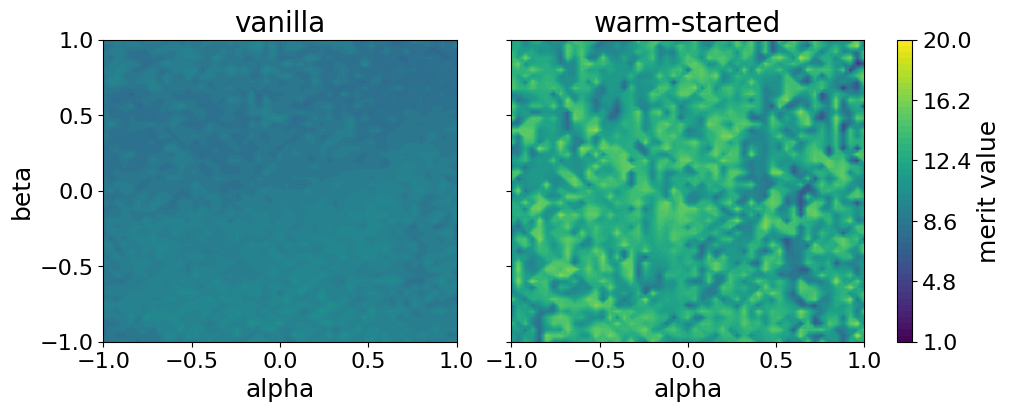

In [69]:
plot_merit_contours_side_by_side(
    vanilla_data["X"], vanilla_data["Y"], vanilla_data["Z"],
    ws_data["X"], ws_data["Y"], ws_data["Z"],
    title_left="vanilla",
    title_right="warm-started",
    n_levels=50,
    vmin=1,
    vmax=20,
    save_path="figures/warmstart_vs_vanilla_merit_contour.png",
    show=True,
    cmap="viridis"
)
